# [Demo] Múltiplos middlewares

Guardrails e human-in-the-loop já empilharam mais de um middleware na mesma lista, cada um cuidando só do
seu problema, sem saber da existência dos outros. Com um middleware só, como em todos os outros exemplos
desta aula, três coisas nunca aparecem: quem roda primeiro, quem vence quando dois escrevem no mesmo
estado, e o que acontece quando um decide encerrar a execução mais cedo. A partir do segundo middleware na
mesma lista, as três passam a importar.

O que vamos ver:
- ordem de execução: `before_model`/`before_agent` direto, `after_model`/`after_agent` invertido,
  `wrap_tool_call` aninhando;
- composição de estado: dois middlewares escrevendo a mesma chave, o reducer decide quem vence;
- `jump_to`: uma saída antecipada corta os middlewares seguintes na lista.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from collections.abc import Callable
from typing import NotRequired

from IPython.display import Image, display
from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import after_model, before_model, wrap_tool_call
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langchain.tools import tool
from langchain.tools.tool_node import ToolCallRequest
from langchain_openai import ChatOpenAI
from langgraph.runtime import Runtime
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

## Ordem de execução

Com mais de um middleware na lista, a ordem de declaração forma camadas: o primeiro da lista é a camada
mais externa, o último é a mais interna. A regra é a mesma nos dois grupos de hooks, só muda a forma como
aparece.

### Node hooks

`before_agent`/`before_model` rodam na ordem da lista; `after_model`/`after_agent` rodam na ordem inversa.
`log_request` e `count_tokens` implementam só `before_model`; `save_result` e `close_trace` implementam só
`after_model`, cada um só imprimindo o próprio nome, pra deixar a ordem visível na saída.

In [4]:
@before_model
def log_request(state: AgentState, runtime: Runtime) -> dict | None:
    print("log_request (before_model)")

In [5]:
@before_model
def count_tokens(state: AgentState, runtime: Runtime) -> dict | None:
    print("count_tokens (before_model)")

In [6]:
@after_model
def save_result(state: AgentState, runtime: Runtime) -> dict | None:
    print("save_result (after_model)")

In [7]:
@after_model
def close_trace(state: AgentState, runtime: Runtime) -> dict | None:
    print("close_trace (after_model)")

In [8]:
order_agent = create_agent(
    model=model,
    tools=[],
    middleware=[log_request, count_tokens, save_result, close_trace],
)

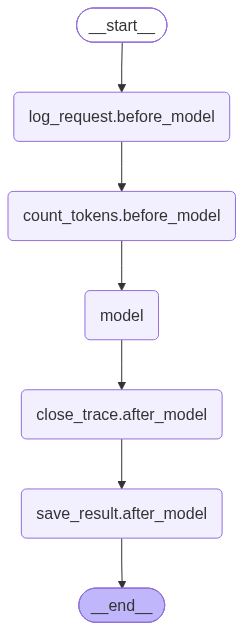

In [9]:
display(Image(order_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [10]:
response = order_agent.invoke({"messages": [HumanMessage("Oi, tudo bem?")]})

log_request (before_model)
count_tokens (before_model)
close_trace (after_model)
save_result (after_model)


A saída mostra `log_request` antes de `count_tokens`, a ordem da lista em `before_model`, e `close_trace`
antes de `save_result`, a ordem inversa em `after_model`: quem foi declarado por último termina primeiro.

### Wrappers

Nos wrappers, a camada é uma função só, que decide quando chamar o que vem depois. `logging_middleware` e
`guardrail_middleware` implementam só `wrap_tool_call`, também só imprimindo o próprio nome na entrada e na
saída.

In [11]:
@wrap_tool_call
def logging_middleware(request: ToolCallRequest, handler: Callable) -> ToolMessage:
    print("logging_middleware: entra")
    result = handler(request)
    print("logging_middleware: sai")
    return result

In [12]:
@wrap_tool_call
def guardrail_middleware(request: ToolCallRequest, handler: Callable) -> ToolMessage:
    print("guardrail_middleware: entra")
    result = handler(request)
    print("guardrail_middleware: sai")
    return result

In [13]:
@tool
def check_status() -> str:
    """Retorna um status fixo, só pra confirmar a ordem dos wrappers."""
    print("check_status: tool real executando")
    return "ok"

In [14]:
wrap_order_agent = create_agent(
    model=model,
    tools=[check_status],
    system_prompt="Você é o assistente da Clínica Alura. Sempre chame a tool check_status quando o usuário perguntar o status.",
    middleware=[logging_middleware, guardrail_middleware],
)

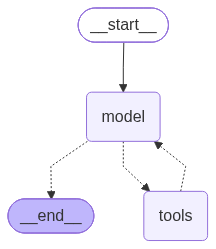

In [15]:
display(Image(wrap_order_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [16]:
response = wrap_order_agent.invoke({"messages": [HumanMessage("Qual o status?")]})

logging_middleware: entra
guardrail_middleware: entra
check_status: tool real executando
guardrail_middleware: sai
logging_middleware: sai


A saída mostra `logging_middleware: entra`, depois `guardrail_middleware: entra`, depois `check_status:
tool real executando`, depois `guardrail_middleware: sai`, e só por último `logging_middleware: sai`:
`logging_middleware`, o primeiro da lista, é mesmo a camada mais externa.

## Composição de estado

`messages` sempre soma: o reducer `add_messages` nunca deixa uma escrita apagar outra. Um campo
customizado sem reducer próprio não tem essa proteção, é overwrite, e quem escreve por último vence. Como
`after_model` roda em ordem inversa, o middleware declarado primeiro na lista é o último a escrever.

In [17]:
class TraceState(AgentState):
    trace: NotRequired[str]

In [18]:
@after_model(state_schema=TraceState)
def mark_outer(state: TraceState, runtime: Runtime) -> dict | None:
    return {"trace": "outer"}

In [19]:
@after_model(state_schema=TraceState)
def mark_inner(state: TraceState, runtime: Runtime) -> dict | None:
    return {"trace": "inner"}

In [20]:
trace_agent = create_agent(
    model=model,
    tools=[],
    middleware=[mark_outer, mark_inner],
)

In [21]:
response = trace_agent.invoke({"messages": [HumanMessage("Oi, tudo bem?")]})
print(response["trace"])

outer


In [22]:
response

{'messages': [HumanMessage(content='Oi, tudo bem?', additional_kwargs={}, response_metadata={}, id='66a03a0e-54b5-4379-95ba-7571fdf59f63'),
  AIMessage(content='Oi! Tudo certo, e você? Como posso ajudar hoje?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 12, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_da56f7d23d', 'id': 'chatcmpl-EK9D96OPZN8XjBlzN4lvHKPjMKd3U', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06928-c441-70c1-ac7a-83d26b4d7790-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 

O estado final tem `trace = "outer"`: `mark_outer`, declarado primeiro, é o último a escrever, porque
`after_model` roda em ordem inversa. `mark_inner` escreveu primeiro, e teve seu valor sobrescrito. Sem um
reducer próprio pra `trace`, quem escreve por último vence, e "por último" é definido pela mesma regra da
seção anterior.

## jump_to

Qualquer hook pode encerrar a execução mais cedo, sem esperar o resto do ciclo: `jump_to="end"` pula direto
pro fim, `jump_to="tools"` pula pro nó de tools, `jump_to="model"` pula de volta pro modelo. Com mais de um
middleware na lista, isso levanta uma pergunta: um `jump_to` de um middleware anterior impede os
middlewares seguintes de rodar?

In [23]:
@before_model(can_jump_to=["end"])
def block_greeting(state: AgentState, runtime: Runtime) -> dict | None:
    last_message = state["messages"][-1]
    if "BLOQUEAR" in last_message.content:
        return {"messages": [AIMessage("Não posso processar esse pedido.")], "jump_to": "end"}
    return None

In [24]:
@before_model
def log_after_block(state: AgentState, runtime: Runtime) -> dict | None:
    print("log_after_block: rodou")

In [25]:
jump_agent = create_agent(
    model=model,
    tools=[],
    middleware=[block_greeting, log_after_block],
)

In [26]:
blocked_response = jump_agent.invoke({"messages": [HumanMessage("BLOQUEAR isso, por favor")]})
print(blocked_response["messages"][-1].content)

Não posso processar esse pedido.


In [27]:
blocked_response

{'messages': [HumanMessage(content='BLOQUEAR isso, por favor', additional_kwargs={}, response_metadata={}, id='5f87233d-a71a-4260-a930-b5fecfbd331f'),
  AIMessage(content='Não posso processar esse pedido.', additional_kwargs={}, response_metadata={}, id='f5d0f5db-64b1-4269-affd-914f235dad6d', tool_calls=[], invalid_tool_calls=[])]}

In [28]:
normal_response = jump_agent.invoke({"messages": [HumanMessage("Oi, tudo bem?")]})
print(normal_response["messages"][-1].content)

log_after_block: rodou
Oi! Tudo bem, e você? Como posso ajudar hoje?


No pedido bloqueado, só a mensagem de recusa aparece: `log_after_block` nunca imprime nada, porque
`block_greeting` interrompeu o ciclo antes dele rodar. No pedido normal, `log_after_block: rodou` aparece e
a resposta vem do modelo, normalmente. Um `jump_to` de um middleware anterior corta os middlewares
seguintes na lista, não só o resto do ciclo do agente.

## Takeaway

Ordem, composição de estado e `jump_to` só importam a partir de dois middlewares na mesma lista. Guardrails
e human-in-the-loop já empilharam middlewares sem se importar com nenhuma dessas três regras, porque suas
peças não colidiam: cada guardrail cuidava de um dado diferente, e o retry envolvia uma tool sem disputar
espaço com a pausa. Quando duas peças colidem de verdade, essas regras decidem quem fala primeiro, quem
escreve por último e quem nunca chega a rodar.